Mounted at /content/drive
🚀 Device : cuda

📂 Chargement datasets...
✅ Classes : ['blanc', 'mixte', 'noir']
   Train : 1623 patches
   Val   : 348 patches
   Test  : 351 patches

📊 Class counts : {'blanc': 541, 'mixte': 541, 'noir': 541}
📊 Class weights : [1. 1. 1.]

🔄 Chargement resnet34...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 190MB/s]


✅ resnet34 prêt

🚀 Entraînement — 10 époques



Epoch [1/10]: 100%|██████████| 102/102 [16:13<00:00,  9.55s/it, loss=0.6036]


Epoch  1/10 | Loss: 0.6062 | Val Acc: 80.75%
   💾 Meilleur modèle sauvegardé (80.75%)


...

Epoch  8/10 | Loss: 0.2416 | Val Acc: 89.94%


Epoch [9/10]: 100%|██████████| 102/102 [00:12<00:00,  8.13it/s, loss=0.1037]


Epoch  9/10 | Loss: 0.2494 | Val Acc: 91.09%


Epoch [10/10]: 100%|██████████| 102/102 [00:12<00:00,  8.11it/s, loss=0.6047]


Epoch 10/10 | Loss: 0.2364 | Val Acc: 92.53%
   💾 Meilleur modèle sauvegardé (92.53%)


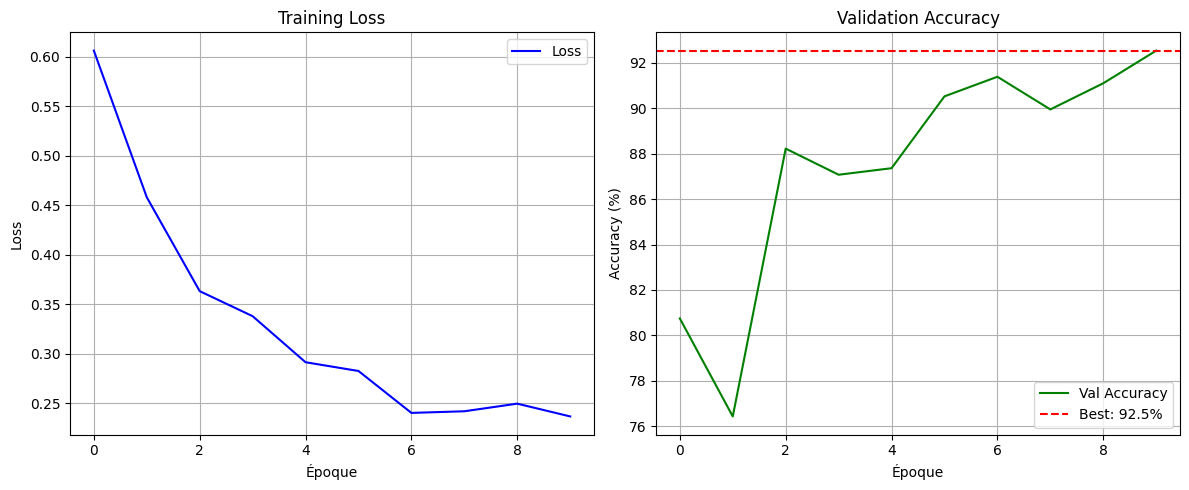


🧪 TEST FINAL

✅ TEST ACCURACY : 89.46%

📊 MATRICE DE CONFUSION :
          blanc     mixte     noir      
blanc            108         5         4
mixte              0        99        18
noir               0        10       107

📋 RAPPORT PAR CLASSE :
              precision    recall  f1-score   support

       blanc       1.00      0.92      0.96       117
       mixte       0.87      0.85      0.86       117
        noir       0.83      0.91      0.87       117

    accuracy                           0.89       351
   macro avg       0.90      0.89      0.90       351
weighted avg       0.90      0.89      0.90       351


🎉 TERMINÉ — Meilleure accuracy : 92.53%
💾 Modèle : /content/drive/MyDrive/resnet34_ecci_A.pth


In [1]:
# -*- coding: utf-8 -*-
"""
TRAIN_RESNET34.py — Version corrigée
Classification ECCI :
    0 = blanc
    1 = noir
    2 = mixte
"""

# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ============================================================
# GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# CHEMINS
# ============================================================
DATASET_DIR = "/content/drive/MyDrive/dislocation_2026/dataset_classification/split"
TRAIN_DIR   = os.path.join(DATASET_DIR, "train")
VAL_DIR     = os.path.join(DATASET_DIR, "val")
TEST_DIR    = os.path.join(DATASET_DIR, "test")
#MODEL_SAVE  = "/content/drive/MyDrive/resnet18_ecci.pth"

# ============================================================
# PARAMÈTRES
# ============================================================
IMAGE_SIZE = 96   # ← corrigé : taille originale des patches
BATCH_SIZE = 16
EPOCHS     = 10   # ← corrigé : plus d'époques
LR         = 1e-4
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Device : {DEVICE}")

# ============================================================
# TRANSFORMATIONS
# ============================================================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ============================================================
# DATASETS
# ============================================================
print("\n📂 Chargement datasets...")

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_transform)

print(f"✅ Classes : {train_dataset.classes}")
print(f"   Train : {len(train_dataset)} patches")
print(f"   Val   : {len(val_dataset)} patches")
print(f"   Test  : {len(test_dataset)} patches")

# ============================================================
# CLASS WEIGHTS — corrigé
# ============================================================
class_counts = [
    len(os.listdir(os.path.join(TRAIN_DIR, c)))
    for c in train_dataset.classes
]
total   = sum(class_counts)
weights = torch.FloatTensor([
    total / (3 * c) for c in class_counts
]).to(DEVICE)

print(f"\n📊 Class counts : {dict(zip(train_dataset.classes, class_counts))}")
print(f"📊 Class weights : {weights.cpu().numpy().round(3)}")

# ============================================================
# DATALOADERS
# ============================================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

# ============================================================
# CHOIX DU MODÈLE
# ============================================================

MODEL_TYPE = "resnet34"
# MODEL_TYPE = "resnet18"

print(f"\n🔄 Chargement {MODEL_TYPE}...")

if MODEL_TYPE == "resnet18":

    model = models.resnet18(weights="DEFAULT")

    MODEL_SAVE = "/content/drive/MyDrive/resnet18_ecci.pth"

elif MODEL_TYPE == "resnet34":

    model = models.resnet34(weights="DEFAULT")

    MODEL_SAVE = "/content/drive/MyDrive/resnet34_ecci_A.pth"

else:
    raise ValueError("MODEL_TYPE doit être 'resnet18' ou 'resnet34'")

# Couche finale : 3 classes
model.fc = nn.Linear(
    model.fc.in_features,
    3
)

model = model.to(DEVICE)

print(f"✅ {MODEL_TYPE} prêt")

# ============================================================
# LOSS + OPTIMIZER + SCHEDULER
# ============================================================
criterion = nn.CrossEntropyLoss(weight=weights)  # ← avec poids
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5,
    factor=0.5
)

# ============================================================
# BOUCLE D'ENTRAÎNEMENT
# ============================================================
best_acc     = 0
train_losses = []
val_accs     = []

print(f"\n🚀 Entraînement — {EPOCHS} époques\n")

for epoch in range(EPOCHS):

    # ── Train ──
    model.train()
    running_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ── Validation ──
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(DEVICE)
            labels  = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    val_accs.append(acc)
    scheduler.step(acc)  # ← scheduler

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"   💾 Meilleur modèle sauvegardé ({acc:.2f}%)")

# ============================================================
# COURBES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, color='blue', label='Loss')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_accs, color='green', label='Val Accuracy')
axes[1].axhline(y=best_acc, color='red', linestyle='--',
                label=f'Best: {best_acc:.1f}%')
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)



plt.tight_layout()

plt.savefig(
    f'/content/drive/MyDrive/courbes_{MODEL_TYPE}.png',
    dpi=100
)

plt.show()
# ============================================================
# TEST FINAL
# ============================================================
print("\n🧪 TEST FINAL")
model.load_state_dict(torch.load(MODEL_SAVE))
model.eval()

all_preds  = []
all_labels = []
correct    = 0
total      = 0

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        labels  = labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
print(f"\n✅ TEST ACCURACY : {test_acc:.2f}%")

# ============================================================
# MATRICE DE CONFUSION
# ============================================================
cm      = confusion_matrix(all_labels, all_preds)
classes = train_dataset.classes

print("\n📊 MATRICE DE CONFUSION :")
print(f"{'':10s}", end="")
for c in classes:
    print(f"{c:10s}", end="")
print()
for i, c in enumerate(classes):
    print(f"{c:10s}", end="")
    for j in range(len(classes)):
        print(f"{cm[i,j]:10d}", end="")
    print()

# ============================================================
# RAPPORT DÉTAILLÉ PAR CLASSE
# ============================================================
print("\n📋 RAPPORT PAR CLASSE :")
print(classification_report(
    all_labels, all_preds,
    target_names=classes
))

print(f"\n🎉 TERMINÉ — Meilleure accuracy : {best_acc:.2f}%")
print(f"💾 Modèle : {MODEL_SAVE}")